In [1]:
library(dplyr)

analyze_celltype_effects <- function(celltype_data){

    fit_int <- lm(percentage ~ Age * sex, data = celltype_data)
    int_summary <- summary(fit_int)
    anova_int <- anova(fit_int)
    
 
    male_fit <- lm(percentage ~ Age, data = subset(celltype_data, sex == "Male"))
    female_fit <- lm(percentage ~ Age, data = subset(celltype_data, sex == "Female"))
    
 
    list(
        interaction = data.frame(
            Age_sex_interaction_p = anova_int["Age:sex", "Pr(>F)"],
            Age_sex_interaction_F = anova_int["Age:sex", "F value"]
        ),
        male = data.frame(
            Age_beta = coef(male_fit)["Age"],
            Age_p = summary(male_fit)$coefficients["Age", "Pr(>|t|)"],
            n_male = nrow(subset(celltype_data, sex == "Male"))
        ),
        female = data.frame(
            Age_beta = coef(female_fit)["Age"],
            Age_p = summary(female_fit)$coefficients["Age", "Pr(>|t|)"],
            n_female = nrow(subset(celltype_data, sex == "Female"))
        )
    )
}




载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
celltype_l4_Proportion = read.csv("CIMA_cell_type_l4_Proportion_by_Sample.csv")

In [3]:
celltype_l4_Proportion

X,sample,celltype,percentage,Sample_name,Age,sex
<int>,<chr>,<chr>,<dbl>,<chr>,<int>,<chr>
0,CIMA_H005,AS_DC,1.107849e-04,CIMA_H005,22,Female
1,CIMA_H006,AS_DC,1.609097e-04,CIMA_H006,22,Female
2,CIMA_H007,AS_DC,2.266674e-04,CIMA_H007,24,Female
3,CIMA_H008,AS_DC,1.241927e-04,CIMA_H008,27,Female
4,CIMA_H009,AS_DC,2.595246e-04,CIMA_H009,29,Female
5,CIMA_H010,AS_DC,1.222643e-04,CIMA_H010,36,Male
6,CIMA_H011,AS_DC,4.232932e-04,CIMA_H011,44,Male
7,CIMA_H012,AS_DC,1.883683e-04,CIMA_H012,70,Female
8,CIMA_H013,AS_DC,1.199976e-04,CIMA_H013,57,Female


In [4]:
# 对所有细胞类型进行分析
all_results <- lapply(
    split(celltype_l4_Proportion, celltype_l4_Proportion$celltype),
    analyze_celltype_effects
)

# 整理结果
final_results <- do.call(rbind, lapply(names(all_results), function(ct){
    data.frame(
        celltype = ct,
        interaction_p = all_results[[ct]]$interaction$Age_sex_interaction_p,
        male_beta = all_results[[ct]]$male$Age_beta,
        male_p = all_results[[ct]]$male$Age_p,
        male_n = all_results[[ct]]$male$n_male,
        female_beta = all_results[[ct]]$female$Age_beta,
        female_p = all_results[[ct]]$female$Age_p,
        female_n = all_results[[ct]]$female$n_female
    )
}))

In [5]:
final_results

celltype,interaction_p,male_beta,male_p,male_n,female_beta,female_p,female_n
<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>
AS_DC,0.23245418,2.866836e-08,9.845763e-01,185,-2.085464e-06,4.818786e-02,236
Atypical_Bm_ITGAX,0.56605163,1.765078e-05,2.158155e-01,185,3.066838e-05,6.650848e-02,236
Bn_IFIT3,0.88039854,-5.780887e-06,5.069452e-01,185,-9.921206e-06,6.701000e-01,236
Bn_IL6,0.76668653,1.233784e-05,1.671821e-01,185,1.683500e-05,1.415132e-01,236
Bn_TCL1A,0.71674325,1.250090e-04,2.305418e-01,185,1.794266e-04,8.724441e-02,236
CD4_CTL_GZMH,0.83937557,3.494942e-04,2.688493e-05,185,3.746562e-04,3.849418e-05,236
CD4_Tcm_CXCR5,0.04074497,1.725749e-05,6.192083e-01,185,1.171383e-04,5.334610e-04,236
CD4_Tcm_IFI44L,0.97038772,-3.699261e-06,8.450599e-01,185,-2.470510e-06,9.218877e-01,236
CD4_Tem_CCR5,0.25197513,1.436902e-06,3.148416e-01,185,4.749970e-06,3.915546e-02,236


In [6]:
write.csv(final_results, "celltype_l4_Proportion_age～sex.csv")

In [7]:
library(ggplot2)
library(dplyr)
library(ggrepel)
library(patchwork)

# Prepare data
plot_data <- final_results %>%
  mutate(
    sig_interaction = ifelse(interaction_p < 0.05, "With interaction", "Without interaction"),
    male_sig = ifelse(male_p < 0.05, "Significant", "Non-significant"),
    female_sig = ifelse(female_p < 0.05, "Significant", "Non-significant"),
    celltype_short = substr(celltype, 1, 20)  # Shorten cell type names
  )

# Plot sex-stratified effects
p1 <- ggplot(plot_data, aes(x = male_beta, y = female_beta)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray70") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray70") +
  geom_abline(intercept = 0, slope = 1, linetype = "dotted", color = "gray50") +
  geom_point(aes(color = sig_interaction, size = abs(male_beta + female_beta)/2), 
             alpha = 0.7) +
  geom_label_repel(
    data = plot_data %>% filter(interaction_p < 0.05 | 
                                abs(male_beta) > 0.15 | 
                                abs(female_beta) > 0.15),
    aes(label = celltype_short),
    size = 3,
    box.padding = 0.3,
    max.overlaps = 20
  ) +
  scale_color_manual(values = c("With interaction" = "red", "Without interaction" = "blue")) +
  labs(
    x = "Male age effect (β, %/year)",
    y = "Female age effect (β, %/year)",
    title = "Sex Comparison of Age Effects",
    subtitle = "Similar effects on diagonal, sex differences off diagonal",
    color = "Interaction",
    size = "Mean effect size"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "right",
    panel.grid.minor = element_blank()
  ) +
  coord_equal(ratio = 1)

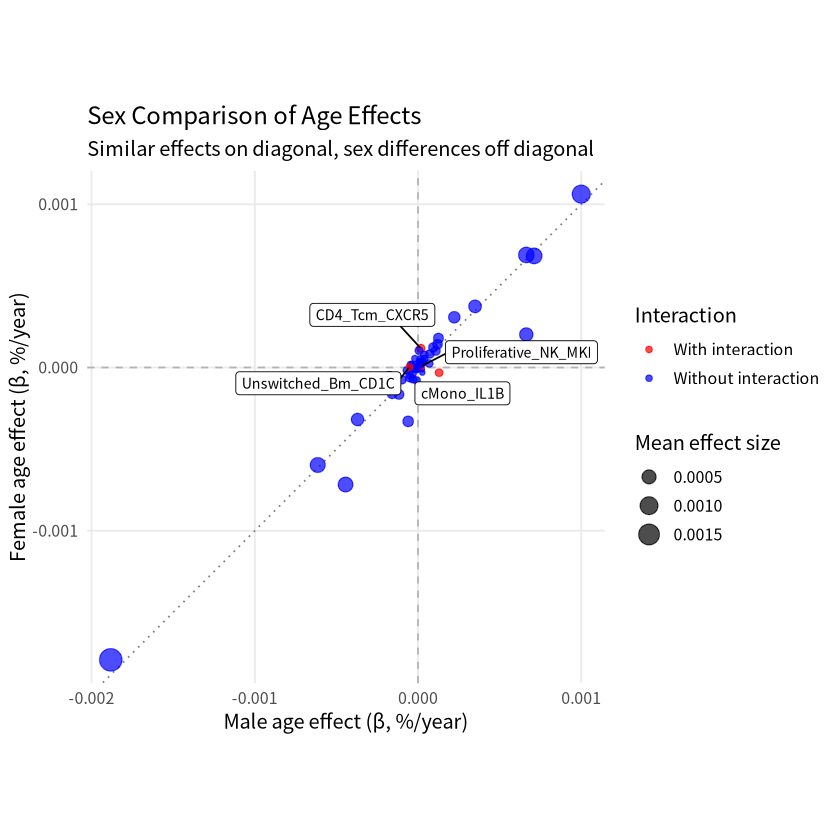

In [8]:
p1

In [9]:
plot_data

celltype,interaction_p,male_beta,male_p,male_n,female_beta,female_p,female_n,sig_interaction,male_sig,female_sig,celltype_short
<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
AS_DC,0.23245418,2.866836e-08,9.845763e-01,185,-2.085464e-06,4.818786e-02,236,Without interaction,Non-significant,Significant,AS_DC
Atypical_Bm_ITGAX,0.56605163,1.765078e-05,2.158155e-01,185,3.066838e-05,6.650848e-02,236,Without interaction,Non-significant,Non-significant,Atypical_Bm_ITGAX
Bn_IFIT3,0.88039854,-5.780887e-06,5.069452e-01,185,-9.921206e-06,6.701000e-01,236,Without interaction,Non-significant,Non-significant,Bn_IFIT3
Bn_IL6,0.76668653,1.233784e-05,1.671821e-01,185,1.683500e-05,1.415132e-01,236,Without interaction,Non-significant,Non-significant,Bn_IL6
Bn_TCL1A,0.71674325,1.250090e-04,2.305418e-01,185,1.794266e-04,8.724441e-02,236,Without interaction,Non-significant,Non-significant,Bn_TCL1A
CD4_CTL_GZMH,0.83937557,3.494942e-04,2.688493e-05,185,3.746562e-04,3.849418e-05,236,Without interaction,Significant,Significant,CD4_CTL_GZMH
CD4_Tcm_CXCR5,0.04074497,1.725749e-05,6.192083e-01,185,1.171383e-04,5.334610e-04,236,With interaction,Non-significant,Significant,CD4_Tcm_CXCR5
CD4_Tcm_IFI44L,0.97038772,-3.699261e-06,8.450599e-01,185,-2.470510e-06,9.218877e-01,236,Without interaction,Non-significant,Non-significant,CD4_Tcm_IFI44L
CD4_Tem_CCR5,0.25197513,1.436902e-06,3.148416e-01,185,4.749970e-06,3.915546e-02,236,Without interaction,Non-significant,Significant,CD4_Tem_CCR5


In [10]:
interaction_data <- plot_data %>%
  arrange(interaction_p) %>%
  mutate(
    rank = 1:n(),
    log10_p = -log10(interaction_p),
    sig_level = cut(interaction_p,
                   breaks = c(0, 0.001, 0.01, 0.05, 1),
                   labels = c("p<0.001", "p<0.01", "p<0.05", "NS"))
  )

p3 <- ggplot(interaction_data, aes(x = reorder(celltype_short, -interaction_p), 
                                   y = log10_p)) +
  geom_bar(aes(fill = sig_level), stat = "identity", width = 0.7) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "red") +
  geom_text(aes(label = ifelse(interaction_p < 0.05, 
                              sprintf("p=%.3f", interaction_p), "")),
            hjust = -0.1, size = 2.8, color = "black") +
  scale_fill_manual(values = c("p<0.001" = "#D32F2F", 
                               "p<0.01" = "#F57C00", 
                               "p<0.05" = "#FBC02D", 
                               "NS" = "#90A4AE")) +
  labs(
    x = "celltype",
    y = "-log10(With interaction p value)",
    title = "Age×sex Interaction Significant",
    fill = "Significant"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 9),
    legend.position = "right"
  ) +
  coord_flip()

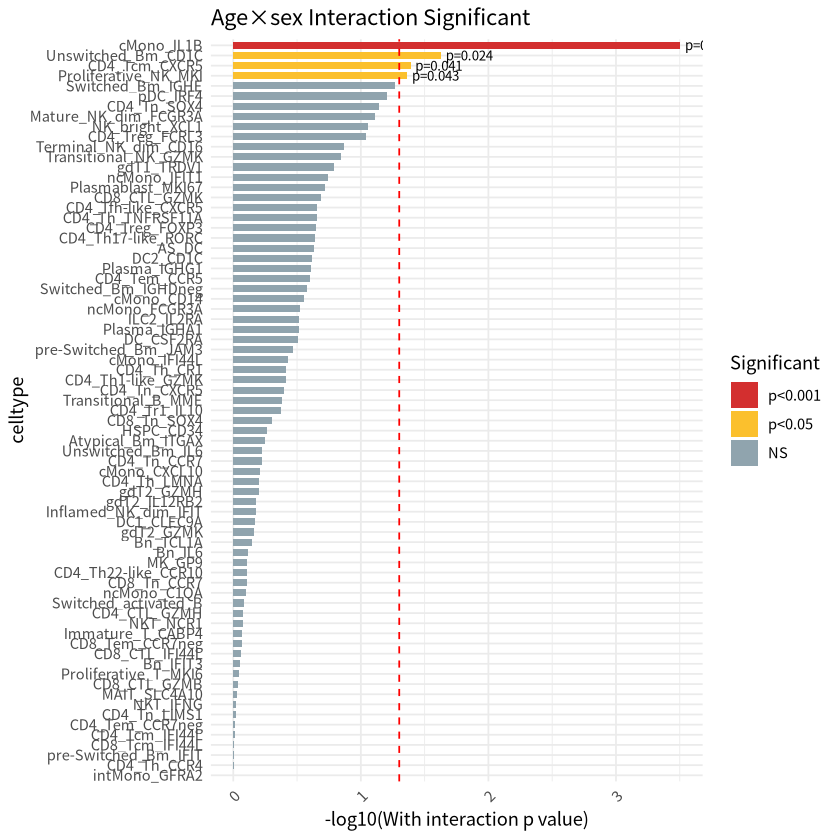

In [11]:
p3 

In [12]:
summary_stats <- plot_data %>%
  group_by(sig_interaction, male_sig, female_sig) %>%
  summarise(
    count = n(),
    percent = round(n() / nrow(plot_data) * 100, 1)
  ) %>%
  arrange(desc(count))

print(summary_stats)


cat("\n=== summary ===\n")
cat("n:", nrow(plot_data), "\n\n")

plot_data %>%
  summarise(

    with_interaction = sum(sig_interaction == "With interaction"),
    without_interaction = sum(sig_interaction == "Without interaction"),
    prop_interaction = mean(sig_interaction == "With interaction") * 100,
    

    male_sig_count = sum(male_sig == "Significant"),
    male_non_sig_count = sum(male_sig == "Non-significant"),
    prop_male_sig = mean(male_sig == "Significant") * 100,
    

    female_sig_count = sum(female_sig == "Significant"),
    female_non_sig_count = sum(female_sig == "Non-significant"),
    prop_female_sig = mean(female_sig == "Significant") * 100
  )

`summarise()` has grouped output by 'sig_interaction', 'male_sig'. You can
override using the `.groups` argument.


# A tibble: 7 × 5
# Groups:   sig_interaction, male_sig [4]
  sig_interaction     male_sig        female_sig      count percent
  <chr>               <chr>           <chr>           <int>   <dbl>
1 Without interaction Non-significant Non-significant    35    47.9
2 Without interaction Significant     Significant        20    27.4
3 Without interaction Non-significant Significant         8    11  
4 Without interaction Significant     Non-significant     6     8.2
5 With interaction    Significant     Non-significant     2     2.7
6 With interaction    Non-significant Significant         1     1.4
7 With interaction    Significant     Significant         1     1.4

=== summary ===
n: 73 



with_interaction,without_interaction,prop_interaction,male_sig_count,male_non_sig_count,prop_male_sig,female_sig_count,female_non_sig_count,prop_female_sig
<int>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>
4,69,5.479452,29,44,39.72603,30,43,41.09589


Warning message:
“The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(count)` instead.”


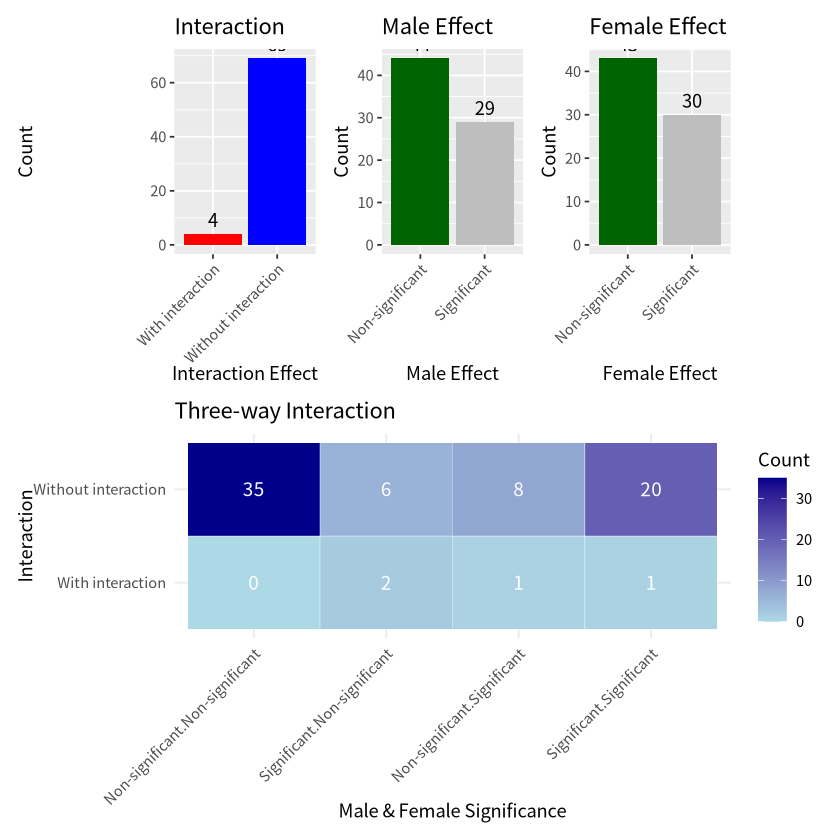

In [13]:
library(ggplot2)
library(patchwork)

p1 <- ggplot(plot_data, aes(x = sig_interaction)) +
  geom_bar(fill = c("With interaction" = "red", "Without interaction" = "blue")) +
  geom_text(stat = 'count', aes(label = ..count..), vjust = -0.5) +
  labs(x = "Interaction Effect", y = "Count", title = "Interaction") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
  #theme_minimal()

p2 <- ggplot(plot_data, aes(x = male_sig)) +
  geom_bar(fill = c("Significant" = "darkgreen", "Non-significant" = "gray")) +
  geom_text(stat = 'count', aes(label = ..count..), vjust = -0.5) +
  labs(x = "Male Effect", y = "Count", title = "Male Effect") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
  #theme_minimal()

p3 <- ggplot(plot_data, aes(x = female_sig)) +
  geom_bar(fill = c("Significant" = "darkgreen", "Non-significant" = "gray")) +
  geom_text(stat = 'count', aes(label = ..count..), vjust = -0.5) +
  labs(x = "Female Effect", y = "Count", title = "Female Effect") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
  #theme_minimal()

cross_table <- as.data.frame(table(
  plot_data$sig_interaction,
  plot_data$male_sig,
  plot_data$female_sig
))
colnames(cross_table) <- c("Interaction", "Male", "Female", "Count")

p4 <- ggplot(cross_table, aes(x = interaction(Male, Female), y = Interaction)) +
  geom_tile(aes(fill = Count), color = "white") +
  geom_text(aes(label = Count), color = "white", size = 4) +
  scale_fill_gradient(low = "lightblue", high = "darkblue") +
  labs(x = "Male & Female Significance", 
       y = "Interaction", 
       title = "Three-way Interaction") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

(p1 + p2 + p3) / p4

In [14]:
# 生成详细统计报告
generate_stats_report <- function(data) {
  cat("===========================================\n")
  cat("          STATISTICAL SUMMARY REPORT       \n")
  cat("===========================================\n\n")
  
  cat("Dataset dimensions:", nrow(data), "rows\n\n")
  
  interaction_stats <- table(data$sig_interaction)
  cat("Interaction Significance:\n")
  cat("  With interaction:", interaction_stats["With interaction"], 
      "(", round(prop.table(interaction_stats)["With interaction"] * 100, 1), "%)\n")
  cat("  Without interaction:", interaction_stats["Without interaction"], 
      "(", round(prop.table(interaction_stats)["Without interaction"] * 100, 1), "%)\n\n")
  
  male_stats <- table(data$male_sig)
  cat("Male Effect Significance:\n")
  cat("  Significant:", male_stats["Significant"], 
      "(", round(prop.table(male_stats)["Significant"] * 100, 1), "%)\n")
  cat("  Non-significant:", male_stats["Non-significant"], 
      "(", round(prop.table(male_stats)["Non-significant"] * 100, 1), "%)\n\n")
  
  female_stats <- table(data$female_sig)
  cat("Female Effect Significance:\n")
  cat("  Significant:", female_stats["Significant"], 
      "(", round(prop.table(female_stats)["Significant"] * 100, 1), "%)\n")
  cat("  Non-significant:", female_stats["Non-significant"], 
      "(", round(prop.table(female_stats)["Non-significant"] * 100, 1), "%)\n\n")
  
  cat("Cross-tabulation: Interaction vs Male Significance\n")
  print(table(data$sig_interaction, data$male_sig))
  cat("\n")
  
  cat("Cross-tabulation: Interaction vs Female Significance\n")
  print(table(data$sig_interaction, data$female_sig))
  cat("\n")
  
  cat("Cross-tabulation: Male vs Female Significance\n")
  print(table(data$male_sig, data$female_sig))
  cat("\n")
}

generate_stats_report(plot_data)

          STATISTICAL SUMMARY REPORT       

Dataset dimensions: 73 rows

Interaction Significance:
  With interaction: 4 ( 5.5 %)
  Without interaction: 69 ( 94.5 %)

Male Effect Significance:
  Significant: 29 ( 39.7 %)
  Non-significant: 44 ( 60.3 %)

Female Effect Significance:
  Significant: 30 ( 41.1 %)
  Non-significant: 43 ( 58.9 %)

Cross-tabulation: Interaction vs Male Significance
                     
                      Non-significant Significant
  With interaction                  1           3
  Without interaction              43          26

Cross-tabulation: Interaction vs Female Significance
                     
                      Non-significant Significant
  With interaction                  2           2
  Without interaction              41          28

Cross-tabulation: Male vs Female Significance
                 
                  Non-significant Significant
  Non-significant              35           9
  Significant                   8          21

